In [1]:
!pip install yfinance

In [2]:
import yfinance as yf

In [3]:
c=yf.download("INTC",start="2024-09-29",end="2026-03-29")
c

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
Date,,,,,
2024-09-30,23.459999,23.950001,23.090000,23.740000,66308200
2024-10-01,22.690001,23.719999,22.260000,23.459999,86344400
2024-10-02,22.389999,23.070000,22.350000,22.670000,59033900
2024-10-03,22.260000,22.730000,21.650000,22.139999,49565900
2024-10-04,22.590000,22.910000,22.299999,22.700001,49845500
...,...,...,...,...,...
2026-03-23,44.009998,45.459999,43.740002,44.500000,80772200
2026-03-24,44.060001,44.310001,43.200001,43.540001,65323500


In [8]:
c.head()

Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
Date,,,,,
2024-09-30,23.459999,23.950001,23.090000,23.740000,66308200
2024-10-01,22.690001,23.719999,22.260000,23.459999,86344400
2024-10-02,22.389999,23.070000,22.350000,22.670000,59033900
2024-10-03,22.260000,22.730000,21.650000,22.139999,49565900
2024-10-04,22.590000,22.910000,22.299999,22.700001,49845500


In [9]:
st=yf.Ticker("INTC")
print(st.info['currentPrice'])

66.26


In [10]:
from statsmodels.tsa.arima.model import ARIMA

In [12]:
ts=c['Close']

In [13]:
from statsmodels.tsa.stattools import adfuller

In [14]:
d=adfuller(ts)
print(d)

(np.float64(-0.7266987683924852), np.float64(0.8397122307332283), 5, 368, {'1%': np.float64(-3.4482453822848496), '5%': np.float64(-2.8694261442901396), '10%': np.float64(-2.5709711770439507)}, np.float64(1196.3607274388198))


In [15]:
tsd=ts.diff().dropna().head()

In [16]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(ts,order=(2,1,2))
model_fit=model.fit()
print(model_fit.summary())

C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   INTC   No. Observations:                  374
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -613.672
Date:                Wed, 22 Apr 2026   AIC                           1237.344
Time:                        16:46:45   BIC                           1256.952
Sample:                             0   HQIC                          1245.130
                                - 374                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7039      0.170      4.132      0.000       0.370       1.038
ar.L2         -0.6885      0.142     -4.840      0.000      -0.967      -0.410
ma.L1         -0.7912      0.187     -4.232      0.0

In [17]:
f=model_fit.forecast(step=4)
print(f)

374    43.35682
dtype: float64


C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['step']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


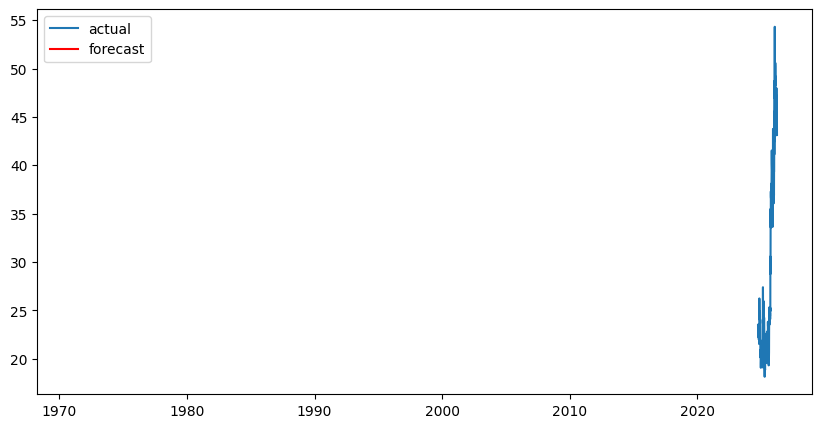

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(ts,label="actual")
plt.plot(f,label="forecast",color="red")
plt.legend()
plt.show()